# Ring–Board group candidate alignment

This notebook selects one WritingRing recording, detects Board press transitions in an explicit raw-timestamp interval, and treats all press-associated Ring windows as a group before any manual anchor is accepted. Common-grid overlays, robust summaries, and heatmaps expose repeatable IMU timing features across events.

The consensus transient feature produces only a **candidate** correction to `coarse_offset_us`; it is not automatically labelled as physical contact and does not replace manually approved anchors. Raw Ring and Board timestamps remain unchanged and in loader-provided order. The old per-event figures remain available as optional diagnostics.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import numpy as np
import pandas as pd
from IPython.display import Image, display

from writingring import (
    build_group_candidate_windows,
    discover_recordings,
    estimate_consensus_shift,
    load_board,
    load_ring,
    nearest_sorted_index,
    plot_group_candidate_heatmap,
    plot_group_candidate_overlay,
    select_recording,
)

## Configuration

Dataset 0 defaults select its observed current Board sequence (numeric chunks 1–6), excluding the older stale tail after the chunk 6→7 backward jump. Bounds are inclusive and are applied only to stored `frame_timestamp_raw` values. Change all recording and interval values together when selecting another recording.

`coarse_offset_us` is only the initial center used for candidate windows. `radius_samples = 2000` is about 10 seconds on each side at the observed rate.

In [2]:
USER = "user_0"
ACTION = "0"
DATASET_ID = 0

BOARD_START_TIMESTAMP = 1720476262355268
BOARD_END_TIMESTAMP = 1720476305908521

coarse_offset_us = 0.0
radius_samples = 2000

SIGNAL_COLUMNS = [
    "acc_x",
    "acc_y",
    "acc_z",
    "gyr_x",
    "gyr_y",
    "gyr_z",
]

CONSENSUS_SEARCH_RANGE_S = (-0.30, 0.30)
GROUP_OVERLAY_NORMALIZED = True
GENERATE_SIGNAL_HEATMAPS = False
GENERATE_SINGLE_EVENT_DIAGNOSTICS = False
DIAGNOSTIC_EVENT_INDICES: list[int] = []

## Discover and load one recording

The project instruction identifies `data_sample/data` as the sample root. This checkout contains the supplied dataset under the legacy `data/` location, so the resolver prefers `data_sample/data` and emits a warning before using `data/` only when the preferred path is absent. Neither location is modified.

`load_ring(recording)` is the existing API and resolves exclusively to the recording's `ring_0` path. Board chunk order is checked numerically before loading.

In [3]:
def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing pyproject.toml")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
preferred_data_root = PROJECT_ROOT / "data_sample" / "data"
legacy_data_root = PROJECT_ROOT / "data"
path_warnings: list[str] = []
if preferred_data_root.is_dir():
    DATA_ROOT = preferred_data_root
elif legacy_data_root.is_dir():
    DATA_ROOT = legacy_data_root
    path_warnings.append(
        "Configured sample root data_sample/data is absent; using the supplied legacy data/ directory."
    )
else:
    raise FileNotFoundError(
        f"Neither sample root exists: {preferred_data_root} or {legacy_data_root}"
    )

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "alignment"
GROUP_RESULTS_DIR = OUTPUT_DIR / "group_candidates"
SINGLE_EVENT_DIAGNOSTIC_DIR = OUTPUT_DIR / "single_event_diagnostics"
GROUP_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

recordings = discover_recordings(DATA_ROOT)
recording = select_recording(
    recordings,
    user=USER,
    action=ACTION,
    dataset_id=DATASET_ID,
)

chunk_indices = recording.board_chunk_indices
if chunk_indices != tuple(sorted(chunk_indices)):
    raise AssertionError(f"Board chunks are not in numeric chunk-index order: {chunk_indices}")

ring_data = load_ring(recording)
board_data = load_board(recording)

print(f"Data root: {DATA_ROOT}")
print(f"Selected: {USER} / action {ACTION} / dataset {DATASET_ID}")
print(f"Loaded Ring source: {ring_data.source_path.name}")
print(f"Board chunks in numeric order: {chunk_indices}")
for warning in path_warnings:
    print(f"WARNING: {warning}")

Data root: /home/ted/project/writingring-viz/data
Selected: user_0 / action 0 / dataset 0
Loaded Ring source: 0_ring_0.bin
Board chunks in numeric order: (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15)


## Select the valid Board interval and report discontinuities

Frames and contacts are independently filtered with identical inclusive raw timestamp bounds. These are copies; the original `BoardData` tables are not reordered, repaired, or pruned. Backward steps are reported for both the complete numeric chunk sequence and the selected interval.

In [4]:
BOARD_DURATION_SECONDS = 20

# 根据 frame_timestamp_raw 的单位设置
BOARD_TIMESTAMP_UNITS_PER_SECOND = 1_000_000 

if board_data.frames.empty:
    raise ValueError("Board data contains no frames")

# loader 提供的第一帧，作为 Board 开始位置
BOARD_START_TIMESTAMP = int(
    board_data.frames["frame_timestamp_raw"].iloc[0]
)

BOARD_END_TIMESTAMP = int(
    BOARD_START_TIMESTAMP
    + BOARD_DURATION_SECONDS * BOARD_TIMESTAMP_UNITS_PER_SECOND
)

print(f"Board start timestamp: {BOARD_START_TIMESTAMP}")
print(f"Board end timestamp:   {BOARD_END_TIMESTAMP}")

if not isinstance(BOARD_START_TIMESTAMP, int) or isinstance(BOARD_START_TIMESTAMP, bool):
    raise TypeError("BOARD_START_TIMESTAMP must be an integer")
if not isinstance(BOARD_END_TIMESTAMP, int) or isinstance(BOARD_END_TIMESTAMP, bool):
    raise TypeError("BOARD_END_TIMESTAMP must be an integer")
if BOARD_START_TIMESTAMP > BOARD_END_TIMESTAMP:
    raise ValueError("BOARD_START_TIMESTAMP must be <= BOARD_END_TIMESTAMP")

board_frames_interval = board_data.frames.loc[
    board_data.frames["frame_timestamp_raw"].between(
        BOARD_START_TIMESTAMP,
        BOARD_END_TIMESTAMP,
        inclusive="both",
    )
].copy()
board_contacts_interval = board_data.contacts.loc[
    board_data.contacts["frame_timestamp_raw"].between(
        BOARD_START_TIMESTAMP,
        BOARD_END_TIMESTAMP,
        inclusive="both",
    )
].copy()
if board_frames_interval.empty:
    raise ValueError("The configured Board interval contains no frames")

full_board_timestamps = board_data.frames["frame_timestamp_raw"].to_numpy(dtype=float)
full_backward_positions = np.flatnonzero(np.diff(full_board_timestamps) < 0) + 1
interval_timestamps = board_frames_interval["frame_timestamp_raw"].to_numpy(dtype=float)
interval_backward_positions = np.flatnonzero(np.diff(interval_timestamps) < 0) + 1

board_warnings: list[str] = []
for boundary in board_data.validation.cross_chunk_backward_boundaries:
    warning = (
        f"Board backward timestamp boundary {boundary.previous_chunk_index}->"
        f"{boundary.next_chunk_index}: delta={boundary.timestamp_delta} raw timestamp units; "
        "reported without repair."
    )
    board_warnings.append(warning)
    print(f"WARNING: {warning}")
if len(interval_backward_positions):
    warning = (
        f"Selected Board interval contains {len(interval_backward_positions)} backward timestamp "
        "step(s); retained without repair."
    )
    board_warnings.append(warning)
    print(f"WARNING: {warning}")

print(
    f"Selected {len(board_frames_interval)} frames and {len(board_contacts_interval)} contacts "
    f"in raw Board interval [{BOARD_START_TIMESTAMP}, {BOARD_END_TIMESTAMP}]."
)
print(f"Full numeric sequence backward steps: {len(full_backward_positions)}")
print(f"Selected interval backward steps: {len(interval_backward_positions)}")

Board start timestamp: 1720476262355268
Board end timestamp:   1720476282355268
Selected 2622 frames and 1332 contacts in raw Board interval [1720476262355268, 1720476282355268].
Full numeric sequence backward steps: 1
Selected interval backward steps: 0


## Detect Board press and lift events

Occupancy means `contact_count > 0`. A press is a `0→1` occupancy transition and a lift is `1→0`, with `prepend=0` exactly as specified. A contact lasting fewer than three selected Board frames is marked `transient`; no event is silently removed. Because the selected interval begins occupied, its first frame is intentionally represented as a press at the interval boundary.

In [5]:
occupied = board_frames_interval["contact_count"].to_numpy() > 0
transition = np.diff(occupied.astype(np.int8), prepend=0)
press_indices = np.flatnonzero(transition == 1)
lift_indices = np.flatnonzero(transition == -1)


def contact_duration_frames(press_index: int) -> int:
    later_lifts = lift_indices[lift_indices > press_index]
    stop = int(later_lifts[0]) if len(later_lifts) else len(occupied)
    return stop - press_index


press_rows: list[dict[str, int | bool]] = []
for event_index, local_frame_index in enumerate(press_indices):
    frame = board_frames_interval.iloc[int(local_frame_index)]
    duration_frames = contact_duration_frames(int(local_frame_index))
    press_rows.append(
        {
            "event_index": event_index,
            "global_frame_index": int(frame["global_frame_index"]),
            "frame_timestamp_raw": int(frame["frame_timestamp_raw"]),
            "chunk_index": int(frame["chunk_index"]),
            "contact_count": int(frame["contact_count"]),
            "duration_frames": duration_frames,
            "transient": duration_frames < 3,
        }
    )

press_events = pd.DataFrame(press_rows)
if press_events.empty:
    raise ValueError("No Board press events were detected in the selected interval")

board_press_events_path = OUTPUT_DIR / "board_press_events.csv"
press_events.to_csv(board_press_events_path, index=False)
print(f"Detected {len(press_events)} presses and {len(lift_indices)} lifts.")
print(f"Transient presses (<3 Board frames): {int(press_events['transient'].sum())}")
display(press_events)

Detected 16 presses and 16 lifts.
Transient presses (<3 Board frames): 0


,event_index,global_frame_index,frame_timestamp_raw,chunk_index,contact_count,duration_frames,transient
0,0,0,1720476262355268,1,1,24,False
1,1,113,1720476263192713,1,1,61,False
2,2,208,1720476263924448,1,1,30,False
3,3,332,1720476264850042,1,1,55,False
4,4,418,1720476265511420,1,1,7,False
5,5,546,1720476266447483,1,1,130,False
6,6,763,1720476268117929,1,1,42,False
7,7,838,1720476268691376,1,1,38,False
8,8,964,1720476269634788,1,1,114,False
9,9,1165,1720476271177001,2,1,109,False


## Reconstruct a strictly increasing Ring time axis

Ring raw timestamps contain repeated values, so they are retained as `timestamp` while a separate `ring_timestamp_reconstructed` column is created on a copied table. The reconstruction interprets raw timestamp differences as microseconds and uses this recording's endpoint-observed sampling rate. This is an explicit working interpretation, not a confirmed upstream unit contract.

In [6]:
ring_timestamps = ring_data.dataframe["timestamp"].to_numpy(copy=True)
sample_count = len(ring_timestamps)
if sample_count < 2:
    raise ValueError("At least two Ring samples are required")

duration_s = (ring_timestamps[-1] - ring_timestamps[0]) / 1_000_000.0
if not np.isfinite(duration_s) or duration_s <= 0:
    raise ValueError(f"Ring endpoint duration must be finite and positive, got {duration_s}")

imu_sampling_rate_hz = (sample_count - 1) / duration_s
ring_timestamp_reconstructed = (
    ring_timestamps[0]
    + np.arange(sample_count, dtype=float) * 1_000_000.0 / imu_sampling_rate_hz
)

ring_dataframe = ring_data.dataframe.copy()
ring_dataframe["ring_timestamp_reconstructed"] = ring_timestamp_reconstructed

print(f"Ring samples: {sample_count}")
print(f"Endpoint duration under microsecond interpretation: {duration_s:.6f} s")
print(f"Recording-specific observed sampling rate: {imu_sampling_rate_hz:.6f} Hz")
print("Reconstructed axis: microsecond interpretation + endpoint-observed sampling rate")

Ring samples: 10247
Endpoint duration under microsecond interpretation: 51.003585 s
Recording-specific observed sampling rate: 200.887840 Hz
Reconstructed axis: microsecond interpretation + endpoint-observed sampling rate


## Six-channel transient score

This robust score is only a visual recommendation aid. It is the norm of median/MAD-normalized first differences across the six channels and is **not** claimed to be the paper's touch-detection method.

In [7]:
signals = ring_dataframe[SIGNAL_COLUMNS].to_numpy()
differences = np.diff(signals, axis=0, prepend=signals[[0]])
difference_median = np.median(differences, axis=0)
difference_mad = np.median(
    np.abs(differences - difference_median),
    axis=0,
)
normalized_differences = (
    differences - difference_median
) / (1.4826 * difference_mad + 1e-12)
transient_score = np.sqrt(np.sum(normalized_differences**2, axis=1))
ring_dataframe["transient_score"] = transient_score

print("Transient score computed as a candidate-selection aid only.")

Transient score computed as a candidate-selection aid only.


## Primary workflow: grouped candidate windows

Each Board press is mapped with the current `coarse_offset_us`. Timestamp bounds—not a uniform-sampling assumption—select local Ring samples. Six IMU channels and the independently computed transient score are interpolated onto a common grid of `2 * radius_samples + 1` points. Interpolation uses local timestamp differences in seconds; outside available Ring coverage remains NaN.

The source timestamps are validated as finite and strictly increasing before `searchsorted` or interpolation. At the observed absolute timestamp magnitude, float64 resolution is about 0.25 microseconds, far below the roughly 5 ms Ring sample spacing.

Accepted 16/16 Board events on a common grid with shape (16, 4001).
Time radius: 2000 nominal samples = 9.955804 s per side.


,board_event_index,board_timestamp_raw,target_imu_timestamp,center_imu_sample_index,window_start_sample_index,window_stop_sample_index_exclusive,nearest_timestamp_error_us,left_coverage_complete,right_coverage_complete,source_sample_count
0,0,1720476262355268,1.720476e+15,1500,0,3500,2185.25,False,True,3500
1,1,1720476263192713,1.720476e+15,1668,0,3668,1027.75,False,True,3668
2,2,1720476263924448,1.720476e+15,1815,0,3815,1044.25,False,True,3815
3,3,1720476264850042,1.720476e+15,2001,1,4001,1340.00,True,True,4000
4,4,1720476265511420,1.720476e+15,2134,134,4134,2023.00,True,True,4000
5,5,1720476266447483,1.720476e+15,2322,322,4322,1805.75,True,True,4000
6,6,1720476268117929,1.720476e+15,2657,658,4658,-1043.00,True,True,4000
7,7,1720476268691376,1.720476e+15,2772,773,4773,-2031.25,True,True,4000
8,8,1720476269634788,1.720476e+15,2962,962,4962,358.00,True,True,4000
9,9,1720476271177001,1.720476e+15,3272,1272,5272,1294.75,True,True,4000


Consensus candidate shift in (-0.3, 0.3): +0.074669 s
Candidate refined offset (not applied): 74668.532 us
coarse_offset_us remains 0.000 us


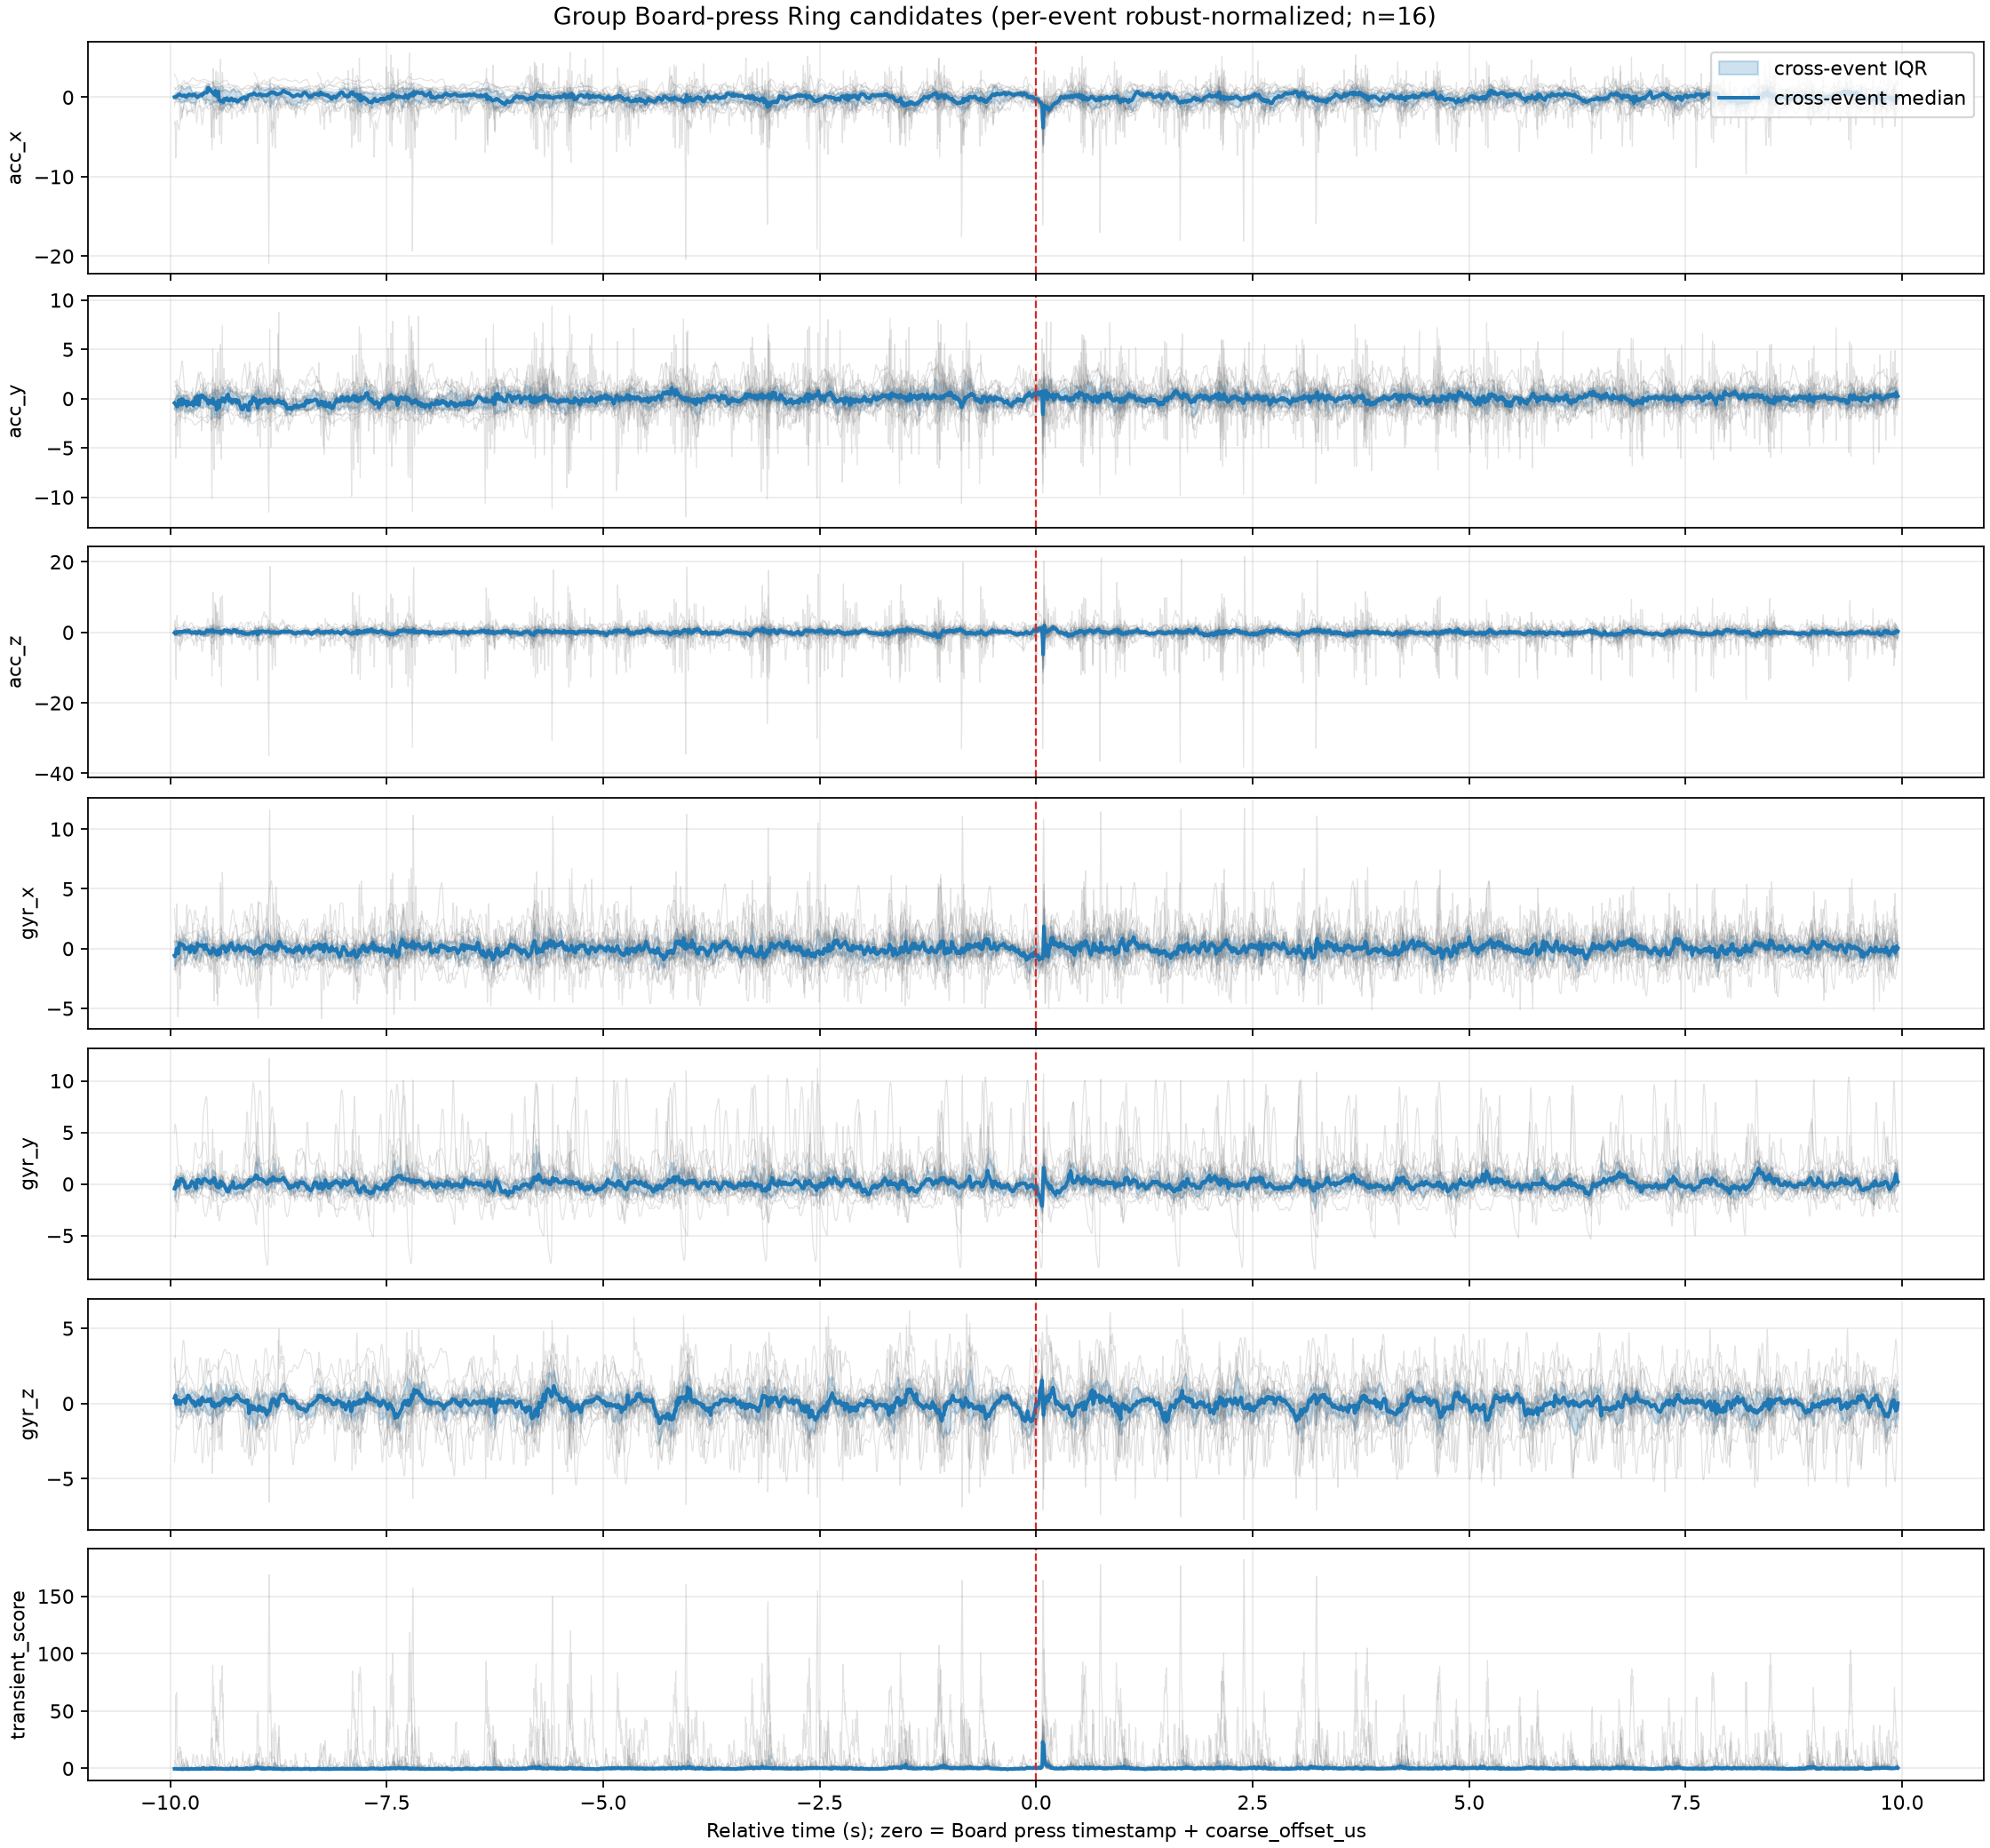

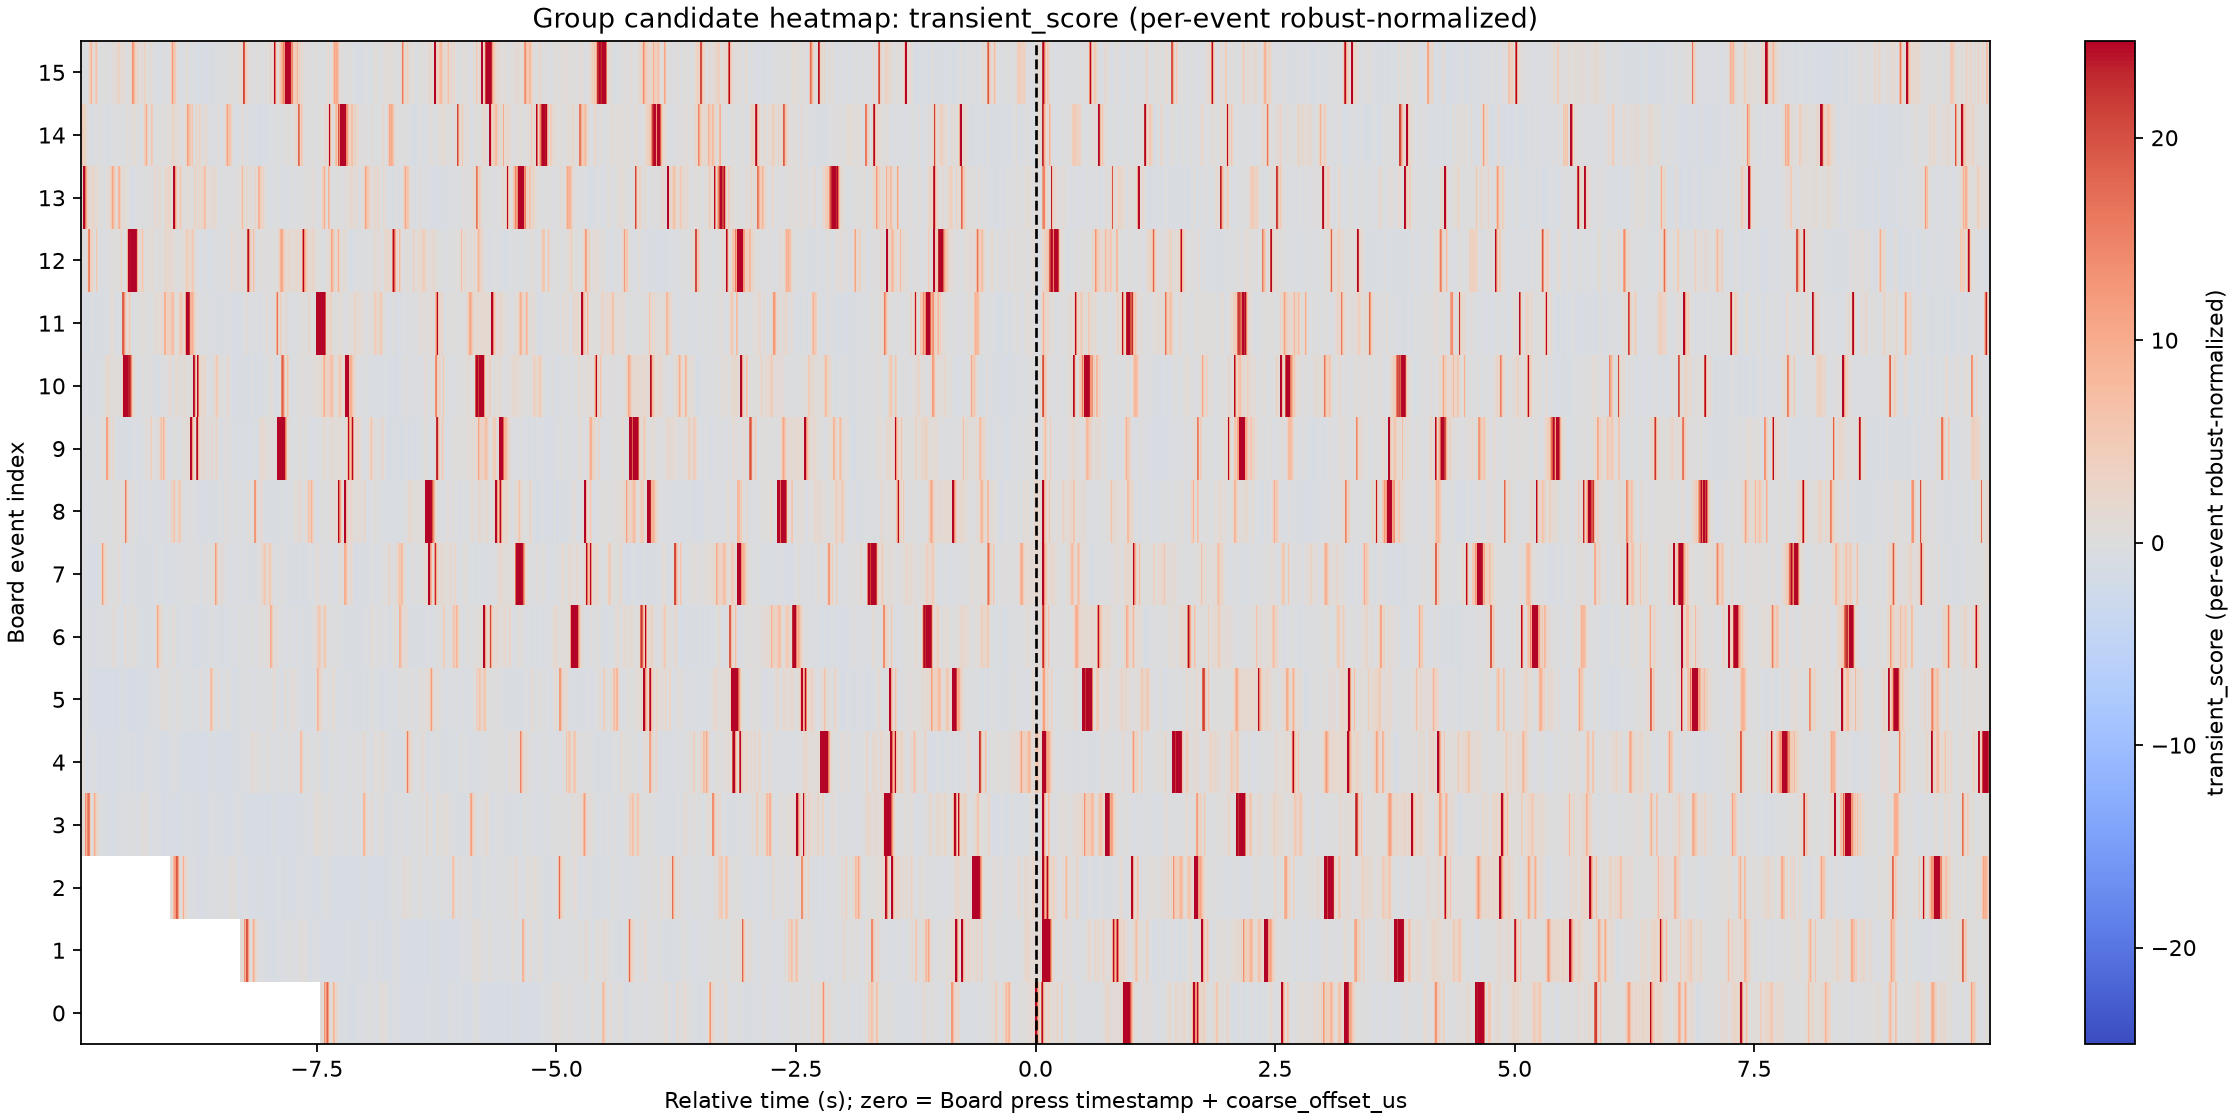

In [8]:
group_candidates = build_group_candidate_windows(
    press_events,
    ring_dataframe,
    ring_timestamp_reconstructed,
    transient_score,
    signal_columns=SIGNAL_COLUMNS,
    coarse_offset_us=coarse_offset_us,
    radius_samples=radius_samples,
    imu_sampling_rate_hz=imu_sampling_rate_hz,
)
if group_candidates.event_count == 0:
    raise ValueError("No Board events have enough Ring coverage for group analysis")

group_relative_time_s = group_candidates.relative_time_s
group_signal_matrices = group_candidates.signal_matrices
group_transient_score_matrix = group_candidates.transient_score_matrix
group_candidate_metadata = group_candidates.metadata
skipped_group_events = group_candidates.skipped_events
approximate_search_radius_seconds = radius_samples / imu_sampling_rate_hz

group_metadata_path = GROUP_RESULTS_DIR / "candidate_window_metadata.csv"
skipped_events_path = GROUP_RESULTS_DIR / "skipped_candidate_events.csv"
group_matrices_path = GROUP_RESULTS_DIR / "group_candidate_matrices.npz"
group_candidate_metadata.to_csv(group_metadata_path, index=False)
skipped_group_events.to_csv(skipped_events_path, index=False)

matrix_payload = {
    "relative_time_s": group_relative_time_s,
    "board_event_indices": group_candidate_metadata["board_event_index"].to_numpy(dtype=int),
    "transient_score": group_transient_score_matrix,
    **{
        signal_name: matrix
        for signal_name, matrix in group_signal_matrices.items()
    },
}
np.savez_compressed(group_matrices_path, **matrix_payload)

partial_coverage = group_candidate_metadata.loc[
    ~(
        group_candidate_metadata["left_coverage_complete"]
        & group_candidate_metadata["right_coverage_complete"]
    )
]
group_warnings: list[str] = []
if not partial_coverage.empty:
    warning = (
        f"{len(partial_coverage)} accepted group event(s) extend outside complete Ring "
        "coverage; unavailable common-grid values remain NaN."
    )
    group_warnings.append(warning)
    print(f"WARNING: {warning}")
if not skipped_group_events.empty:
    warning = (
        f"Skipped {len(skipped_group_events)} event(s) with fewer than two Ring samples; "
        "see skipped_candidate_events.csv."
    )
    group_warnings.append(warning)
    print(f"WARNING: {warning}")

print(
    f"Accepted {group_candidates.event_count}/{len(press_events)} Board events on a "
    f"common grid with shape ({group_candidates.event_count}, {group_candidates.time_count})."
)
print(
    f"Time radius: {radius_samples} nominal samples = "
    f"{approximate_search_radius_seconds:.6f} s per side."
)
display(group_candidate_metadata)
if not skipped_group_events.empty:
    display(skipped_group_events)

group_overlay_path = GROUP_RESULTS_DIR / "group_overlay_normalized.png"
group_overlay_figure = plot_group_candidate_overlay(
    group_candidates,
    normalized=GROUP_OVERLAY_NORMALIZED,
    output_path=group_overlay_path,
    show=False,
)
plt.close(group_overlay_figure)

transient_heatmap_path = GROUP_RESULTS_DIR / "transient_score_heatmap.png"
transient_heatmap_figure = plot_group_candidate_heatmap(
    group_candidates,
    signal_name="transient_score",
    normalized=True,
    output_path=transient_heatmap_path,
    show=False,
)
plt.close(transient_heatmap_figure)

signal_heatmap_paths: list[Path] = []
if GENERATE_SIGNAL_HEATMAPS:
    for signal_name in SIGNAL_COLUMNS:
        signal_heatmap_path = GROUP_RESULTS_DIR / f"{signal_name}_heatmap.png"
        signal_heatmap_figure = plot_group_candidate_heatmap(
            group_candidates,
            signal_name=signal_name,
            normalized=True,
            output_path=signal_heatmap_path,
            show=False,
        )
        plt.close(signal_heatmap_figure)
        signal_heatmap_paths.append(signal_heatmap_path)

consensus_result = estimate_consensus_shift(
    group_relative_time_s,
    group_transient_score_matrix,
    coarse_offset_us=coarse_offset_us,
    search_range_s=CONSENSUS_SEARCH_RANGE_S,
)
consensus_candidate_path = GROUP_RESULTS_DIR / "consensus_offset_candidate.json"
consensus_candidate = {
    "search_range_s": list(consensus_result.search_range_s),
    "consensus_shift_s": consensus_result.consensus_shift_s,
    "candidate_refined_offset_us": consensus_result.candidate_refined_offset_us,
    "coarse_offset_us_unchanged": coarse_offset_us,
    "contributing_event_count": consensus_result.contributing_event_count,
    "interpretation": (
        "Candidate refinement only; the strongest common transient is not "
        "automatically declared to be physical Board contact."
    ),
}
consensus_candidate_path.write_text(
    json.dumps(consensus_candidate, indent=2) + "\n",
    encoding="utf-8",
)

print(
    f"Consensus candidate shift in {CONSENSUS_SEARCH_RANGE_S}: "
    f"{consensus_result.consensus_shift_s:+.6f} s"
)
print(
    "Candidate refined offset (not applied): "
    f"{consensus_result.candidate_refined_offset_us:.3f} us"
)
print(f"coarse_offset_us remains {coarse_offset_us:.3f} us")
display(Image(filename=str(group_overlay_path)))
display(Image(filename=str(transient_heatmap_path)))

## Optional single-event diagnostics

The group overlay and heatmap are the primary selection evidence. The original seven-panel per-event view remains available for outliers or ambiguous cases. Set `GENERATE_SINGLE_EVENT_DIAGNOSTICS = True`; an empty `DIAGNOSTIC_EVENT_INDICES` then means all available events. These figures do not automatically identify touch samples.

In [9]:
def plot_candidate_window(
    press_event: pd.Series,
    *,
    output_path: Path,
) -> tuple[Figure, int, int, int]:
    board_press_timestamp = int(press_event["frame_timestamp_raw"])
    target_imu_timestamp = board_press_timestamp + coarse_offset_us
    center_index = nearest_sorted_index(
        ring_timestamp_reconstructed,
        target_imu_timestamp,
    )
    start = max(0, center_index - radius_samples)
    stop = min(len(ring_dataframe), center_index + radius_samples + 1)
    if stop - start < 2:
        raise ValueError(
            f"Board event {int(press_event['event_index'])} has fewer than two Ring samples"
        )
    relative_time_s = (
        ring_timestamp_reconstructed[start:stop] - target_imu_timestamp
    ) / 1_000_000.0

    figure, axes = plt.subplots(
        7,
        1,
        figsize=(14, 13),
        sharex=True,
        layout="constrained",
    )
    for axis, signal_name in zip(axes[:6], SIGNAL_COLUMNS, strict=True):
        axis.plot(
            relative_time_s,
            ring_dataframe[signal_name].iloc[start:stop].to_numpy(),
            linewidth=0.8,
        )
        axis.set_ylabel(signal_name)
        axis.axvline(0.0, color="tab:red", linestyle="--", linewidth=1.0)
        axis.grid(True, alpha=0.25)
    axes[6].plot(
        relative_time_s,
        transient_score[start:stop],
        color="black",
        linewidth=0.8,
    )
    axes[6].set_ylabel("transient\nscore")
    axes[6].set_xlabel(
        "Relative time (s); zero = Board press timestamp + coarse_offset_us"
    )
    axes[6].axvline(0.0, color="tab:red", linestyle="--", linewidth=1.0)
    axes[6].grid(True, alpha=0.25)
    figure.suptitle(
        f"Diagnostic Board press {int(press_event['event_index']):03d} | "
        f"Board raw timestamp={board_press_timestamp} | "
        f"coarse offset={coarse_offset_us:.1f} us\n"
        f"nearest Ring sample={center_index} | sample window=[{start}, {stop})"
    )
    output_path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(output_path, dpi=140)
    return figure, center_index, start, stop


available_event_indices = press_events["event_index"].astype(int).tolist()
diagnostic_event_indices = (
    DIAGNOSTIC_EVENT_INDICES
    if DIAGNOSTIC_EVENT_INDICES
    else available_event_indices
)
diagnostic_output_paths: list[Path] = []
if GENERATE_SINGLE_EVENT_DIAGNOSTICS:
    invalid_diagnostic_indices = sorted(
        set(diagnostic_event_indices) - set(available_event_indices)
    )
    if invalid_diagnostic_indices:
        raise ValueError(
            f"Unknown diagnostic Board event indices: {invalid_diagnostic_indices}"
        )
    event_lookup_for_diagnostics = press_events.set_index("event_index")
    for event_index in diagnostic_event_indices:
        output_path = SINGLE_EVENT_DIAGNOSTIC_DIR / f"press_{event_index:03d}.png"
        figure, _, _, _ = plot_candidate_window(
            event_lookup_for_diagnostics.loc[event_index],
            output_path=output_path,
        )
        plt.close(figure)
        diagnostic_output_paths.append(output_path)
    print(f"Saved {len(diagnostic_output_paths)} optional single-event diagnostics.")
else:
    print("Optional single-event diagnostics are disabled; group analysis is primary.")

Optional single-event diagnostics are disabled; group analysis is primary.


## Manual alignment anchors after group review

Inspect the group overlay, heatmap, and candidate consensus first; decide which repeatable landmark is being used; then verify each chosen event against the group feature or an optional individual diagnostic.

The existing anchor event numbers below are preserved exactly. Because the current user-configured Board interval is 20 seconds, some anchors refer to events outside the available set. They are reported as invalid and excluded from the provisional manual fit—never renumbered or silently reassigned.

In [ ]:
MANUAL_ANCHORS = [
    {
        "board_event_index": 1,
        "imu_sample_index": 1686,
        "signal_name": "acc_x",
        "confidence": "high",
        "notes": "Distinct contact transient in candidate window.",
    },
    {
        "board_event_index": 4,
        "imu_sample_index": 2150,
        "signal_name": "acc_z",
        "confidence": "high",
        "notes": "Distinct contact transient in candidate window.",
    },
    {
        "board_event_index": 8,
        "imu_sample_index": 2979,
        "signal_name": "acc_z",
        "confidence": "high",
        "notes": "Distinct contact transient in candidate window.",
    },
    {
        "board_event_index": 14,
        "imu_sample_index": 5172,
        "signal_name": "acc_z",
        "confidence": "high",
        "notes": "Distinct contact transient in candidate window.",
    },
    {
        "board_event_index": 20,
        "imu_sample_index": 6803,
        "signal_name": "acc_z",
        "confidence": "high",
        "notes": "Distinct contact transient in candidate window.",
    },
    {
        "board_event_index": 24,
        "imu_sample_index": 8242,
        "signal_name": "acc_x",
        "confidence": "high",
        "notes": "Distinct contact transient in candidate window.",
    },
    {
        "board_event_index": 25,
        "imu_sample_index": 8636,
        "signal_name": "acc_z",
        "confidence": "high",
        "notes": "Distinct contact transient in candidate window.",
    },
    {
        "board_event_index": 26,
        "imu_sample_index": 9050,
        "signal_name": "acc_z",
        "confidence": "medium",
        "notes": "Lower-amplitude but isolated contact transient.",
    },
    {
        "board_event_index": 28,
        "imu_sample_index": 9478,
        "signal_name": "acc_z",
        "confidence": "high",
        "notes": "Distinct contact transient in candidate window.",
    },
    {
        "board_event_index": 30,
        "imu_sample_index": 10031,
        "signal_name": "acc_z",
        "confidence": "high",
        "notes": "Distinct contact transient in candidate window.",
    },
]

### Anchor validation

The validation table shows every configured anchor, all available Board event indices, duplicates, invalid references, and the subset eligible for offset estimation.

In [ ]:
required_manual_fields = {
    "board_event_index",
    "imu_sample_index",
    "signal_name",
    "confidence",
    "notes",
}
available_board_event_indices = press_events["event_index"].astype(int).tolist()
available_board_event_index_set = set(available_board_event_indices)
configured_integer_event_indices = [
    anchor.get("board_event_index")
    for anchor in MANUAL_ANCHORS
    if isinstance(anchor.get("board_event_index"), int)
    and not isinstance(anchor.get("board_event_index"), bool)
]
duplicate_board_event_indices = {
    event_index
    for event_index in configured_integer_event_indices
    if configured_integer_event_indices.count(event_index) > 1
}
event_lookup = press_events.set_index("event_index")
anchor_rows: list[dict[str, int | float | str]] = []
anchor_validation_rows: list[dict[str, int | str | None]] = []

for anchor_number, anchor in enumerate(MANUAL_ANCHORS):
    issues: list[str] = []
    missing_fields = required_manual_fields - anchor.keys()
    if missing_fields:
        issues.append(f"missing fields: {sorted(missing_fields)}")

    board_event_index = anchor.get("board_event_index")
    imu_sample_index = anchor.get("imu_sample_index")
    valid_event_index = (
        isinstance(board_event_index, int)
        and not isinstance(board_event_index, bool)
    )
    valid_sample_index = (
        isinstance(imu_sample_index, int)
        and not isinstance(imu_sample_index, bool)
    )
    if not valid_event_index:
        issues.append("board_event_index must be an integer")
    elif board_event_index not in available_board_event_index_set:
        issues.append("Board event is not available in the selected interval")
    if valid_event_index and board_event_index in duplicate_board_event_indices:
        issues.append("Board event is used by more than one anchor")
    if not valid_sample_index:
        issues.append("imu_sample_index must be an integer")
    elif not 0 <= imu_sample_index < len(ring_dataframe):
        issues.append("Ring sample index is outside available data")
    if anchor.get("signal_name") not in SIGNAL_COLUMNS:
        issues.append("signal_name is not a configured Ring signal")

    status = "valid" if not issues else "invalid"
    anchor_validation_rows.append(
        {
            "anchor_number": anchor_number,
            "board_event_index": board_event_index,
            "imu_sample_index": imu_sample_index,
            "status": status,
            "issues": "; ".join(issues),
        }
    )
    if issues:
        continue

    board_timestamp_raw = int(event_lookup.loc[board_event_index, "frame_timestamp_raw"])
    imu_timestamp_reconstructed = float(
        ring_timestamp_reconstructed[imu_sample_index]
    )
    anchor_rows.append(
        {
            "board_event_index": board_event_index,
            "board_timestamp_raw": board_timestamp_raw,
            "imu_sample_index": imu_sample_index,
            "imu_timestamp_reconstructed": imu_timestamp_reconstructed,
            "signal_name": str(anchor["signal_name"]),
            "confidence": str(anchor["confidence"]),
            "notes": str(anchor["notes"]),
            "offset_us": imu_timestamp_reconstructed - board_timestamp_raw,
        }
    )

manual_anchor_validation = pd.DataFrame(anchor_validation_rows)
invalid_manual_anchors = manual_anchor_validation.loc[
    manual_anchor_validation["status"] == "invalid"
].copy()
alignment_anchors = pd.DataFrame(anchor_rows)
manual_anchor_validation_path = OUTPUT_DIR / "manual_anchor_validation.csv"
manual_anchor_validation.to_csv(manual_anchor_validation_path, index=False)

print(f"Available Board event indices: {available_board_event_indices}")
print(f"Duplicate configured Board event indices: {sorted(duplicate_board_event_indices)}")
print(
    f"Manual anchors: {len(alignment_anchors)} valid, "
    f"{len(invalid_manual_anchors)} invalid."
)
display(manual_anchor_validation)
if not invalid_manual_anchors.empty:
    display(invalid_manual_anchors)
if alignment_anchors.empty:
    raise ValueError("No valid manual anchors remain after explicit validation")

manual_anchor_warnings: list[str] = []
if not invalid_manual_anchors.empty:
    manual_anchor_warnings.append(
        f"{len(invalid_manual_anchors)} manual anchor(s) are invalid for the selected interval; "
        "they were reported and excluded without renumbering."
    )
if len(alignment_anchors) < 5:
    warning = (
        f"Only {len(alignment_anchors)} valid manual anchors remain; at least five are recommended."
    )
    manual_anchor_warnings.append(warning)
    print(f"WARNING: {warning}")

print("Valid anchor offset distribution before median fitting (microseconds):")
display(alignment_anchors["offset_us"].describe())

## Estimate the constant offset and inspect residuals

The fixed offset is the median of `imu_timestamp_reconstructed - board_timestamp_raw`. Residuals are kept in microseconds and plotted in milliseconds. A least-squares residual trend is diagnostic only; even when the simple threshold flags possible drift, no affine correction is fitted or applied.

In [ ]:
anchor_offsets_us = alignment_anchors["offset_us"].to_numpy(dtype=float)
fixed_offset_us = float(np.median(anchor_offsets_us))
residual_us = anchor_offsets_us - fixed_offset_us
alignment_anchors["residual_us"] = residual_us

absolute_residual_ms = np.abs(residual_us) / 1_000.0
median_absolute_residual_ms = float(np.median(absolute_residual_ms))
maximum_absolute_residual_ms = float(np.max(absolute_residual_ms))
p95_absolute_residual_ms = float(np.percentile(absolute_residual_ms, 95))

anchor_elapsed_s = (
    alignment_anchors["imu_timestamp_reconstructed"].to_numpy(dtype=float)
    - ring_timestamp_reconstructed[0]
) / 1_000_000.0
drift_warning: str | None = None
if len(alignment_anchors) >= 3 and np.ptp(anchor_elapsed_s) > 0:
    slope_ms_per_s, intercept_ms = np.polyfit(
        anchor_elapsed_s,
        residual_us / 1_000.0,
        1,
    )
    fitted_change_ms = float(abs(slope_ms_per_s * np.ptp(anchor_elapsed_s)))
    if fitted_change_ms > 5.0:
        drift_warning = (
            f"Residual trend changes by about {fitted_change_ms:.3f} ms over the anchor span; "
            "possible clock drift is reported but not corrected."
        )
else:
    slope_ms_per_s = float("nan")
    intercept_ms = float("nan")

warnings_output = [
    *path_warnings,
    *board_warnings,
    *group_warnings,
    *manual_anchor_warnings,
]
if drift_warning is not None:
    warnings_output.append(drift_warning)
    print(f"WARNING: {drift_warning}")

anchor_residuals_path = OUTPUT_DIR / "anchor_residuals.png"
residual_figure, residual_axis = plt.subplots(figsize=(10, 5), layout="constrained")
residual_axis.scatter(anchor_elapsed_s, residual_us / 1_000.0, color="tab:blue")
residual_axis.axhline(0.0, color="black", linewidth=1.0)
if len(alignment_anchors) >= 3 and np.ptp(anchor_elapsed_s) > 0:
    fitted_residual_ms = slope_ms_per_s * anchor_elapsed_s + intercept_ms
    residual_axis.plot(
        anchor_elapsed_s,
        fitted_residual_ms,
        color="tab:orange",
        linestyle="--",
        label="diagnostic linear trend (not applied)",
    )
    residual_axis.legend()
residual_axis.set_xlabel("Anchor elapsed Ring reconstructed time (s)")
residual_axis.set_ylabel("Constant-offset residual (ms)")
residual_axis.set_title(
    f"Manual anchor residuals | fixed offset={fixed_offset_us:.3f} us"
)
residual_axis.grid(True, alpha=0.3)
residual_figure.savefig(anchor_residuals_path, dpi=160)
plt.show()

print(f"Anchor count: {len(alignment_anchors)}")
print(f"Fixed offset: {fixed_offset_us:.3f} us")
print(f"Median absolute residual: {median_absolute_residual_ms:.3f} ms")
print(f"Maximum absolute residual: {maximum_absolute_residual_ms:.3f} ms")
print(f"P95 absolute residual: {p95_absolute_residual_ms:.3f} ms")
display(alignment_anchors)

## Aligned overview and exported diagnostics

Every Board press is mapped into reconstructed Ring time by adding the single median offset. The overview compares the Ring transient score, all mapped Board presses, and the manual IMU peak anchors on one Ring reconstructed elapsed-time axis.

In [ ]:
aligned_board_press_timestamp = (
    press_events["frame_timestamp_raw"].to_numpy(dtype=float) + fixed_offset_us
)
ring_elapsed_s = (
    ring_timestamp_reconstructed - ring_timestamp_reconstructed[0]
) / 1_000_000.0
aligned_press_elapsed_s = (
    aligned_board_press_timestamp - ring_timestamp_reconstructed[0]
) / 1_000_000.0
anchor_peak_elapsed_s = (
    alignment_anchors["imu_timestamp_reconstructed"].to_numpy(dtype=float)
    - ring_timestamp_reconstructed[0]
) / 1_000_000.0

overlay_path = OUTPUT_DIR / "aligned_event_overlay.png"
overlay_figure, overlay_axis = plt.subplots(figsize=(15, 6), layout="constrained")
overlay_axis.plot(
    ring_elapsed_s,
    transient_score,
    color="black",
    linewidth=0.7,
    label="Ring transient score (visual aid)",
)
for index, elapsed_s in enumerate(aligned_press_elapsed_s):
    overlay_axis.axvline(
        elapsed_s,
        color="tab:red",
        alpha=0.35,
        linewidth=0.9,
        label="Board press + fixed offset" if index == 0 else None,
    )
anchor_scores = np.interp(
    anchor_peak_elapsed_s,
    ring_elapsed_s,
    transient_score,
)
overlay_axis.scatter(
    anchor_peak_elapsed_s,
    anchor_scores,
    marker="x",
    s=65,
    linewidths=2.0,
    color="tab:blue",
    label="Manual IMU peak anchor",
    zorder=3,
)
overlay_axis.set_xlabel("Ring reconstructed elapsed time (s)")
overlay_axis.set_ylabel("Transient score (dimensionless visual aid)")
overlay_axis.set_title(
    f"Ring–Board constant-offset alignment | {USER}/action {ACTION}/dataset {DATASET_ID}"
)
overlay_axis.grid(True, alpha=0.25)
overlay_axis.legend()
overlay_figure.savefig(overlay_path, dpi=160)
plt.show()

alignment_anchors_path = OUTPUT_DIR / "alignment_anchors.csv"
alignment_anchors.to_csv(alignment_anchors_path, index=False)

report = {
    "recording": {
        "user": USER,
        "action": ACTION,
        "dataset_id": DATASET_ID,
    },
    "ring_source": str(ring_data.source_path),
    "ring_time_axis": (
        "ring_timestamp_reconstructed; microsecond interpretation using "
        "recording-specific endpoint-observed sampling rate"
    ),
    "board_interval": {
        "start_timestamp_raw": BOARD_START_TIMESTAMP,
        "end_timestamp_raw": BOARD_END_TIMESTAMP,
        "inclusive": True,
    },
    "board_press_count": len(press_events),
    "ring_sampling_rate_hz": imu_sampling_rate_hz,
    "search_radius_samples": radius_samples,
    "approximate_search_radius_seconds": approximate_search_radius_seconds,
    "coarse_offset_us": coarse_offset_us,
    "group_candidates": {
        "accepted_event_count": group_candidates.event_count,
        "skipped_event_count": len(skipped_group_events),
        "time_sample_count": group_candidates.time_count,
        "signal_matrix_shapes": {
            name: list(matrix.shape)
            for name, matrix in group_signal_matrices.items()
        },
        "transient_score_matrix_shape": list(group_transient_score_matrix.shape),
    },
    "candidate_offset_refinement": consensus_candidate,
    "alignment_model": "constant_offset",
    "fixed_offset_us": fixed_offset_us,
    "anchor_count": len(alignment_anchors),
    "invalid_anchor_count": len(invalid_manual_anchors),
    "median_absolute_residual_ms": median_absolute_residual_ms,
    "maximum_absolute_residual_ms": maximum_absolute_residual_ms,
    "p95_absolute_residual_ms": p95_absolute_residual_ms,
    "warnings": warnings_output,
}
alignment_report_path = OUTPUT_DIR / "alignment_report.json"
alignment_report_path.write_text(
    json.dumps(report, indent=2, ensure_ascii=False) + "\n",
    encoding="utf-8",
)
display(report)

## Required checks

These checks verify the selected Ring stream, exact search radius, reconstructed monotonicity, anchor bounds, and every required non-empty output. Candidate filenames are also checked one-for-one against detected Board presses.

In [ ]:
assert ring_data.source_path.name.endswith("_ring_0.bin")
assert radius_samples == 2000
assert np.all(np.isfinite(ring_timestamp_reconstructed))
assert np.all(np.diff(ring_timestamp_reconstructed) > 0)
assert group_candidates.event_count + len(skipped_group_events) == len(press_events)
assert group_relative_time_s.shape == (2 * radius_samples + 1,)
assert group_transient_score_matrix.shape == (
    group_candidates.event_count,
    len(group_relative_time_s),
)
assert all(
    matrix.shape == group_transient_score_matrix.shape
    for matrix in group_signal_matrices.values()
)
assert all(
    0 <= anchor["imu_sample_index"] < len(ring_data.dataframe)
    for anchor in MANUAL_ANCHORS
)
assert set(alignment_anchors["board_event_index"]).issubset(
    set(available_board_event_indices)
)

required_output_paths = [
    board_press_events_path,
    group_metadata_path,
    skipped_events_path,
    group_matrices_path,
    group_overlay_path,
    transient_heatmap_path,
    consensus_candidate_path,
    manual_anchor_validation_path,
    alignment_anchors_path,
    alignment_report_path,
    anchor_residuals_path,
    overlay_path,
    *signal_heatmap_paths,
    *diagnostic_output_paths,
]
for output_path in required_output_paths:
    assert output_path.is_file(), f"Missing output: {output_path}"
    assert output_path.stat().st_size > 0, f"Empty output: {output_path}"

print("All required group-alignment checks passed.")
print(f"Outputs: {OUTPUT_DIR}")
for output_path in required_output_paths:
    print(f"- {output_path.relative_to(PROJECT_ROOT)} ({output_path.stat().st_size:,} bytes)")

## Intentional differences from upstream reference scripts

- `vendor/WritingRing/ring_plot.py` reads native `float64` rows and uses nearest raw timestamps. This notebook preserves those verified seven-column semantics through `load_ring`, but adds a separately named strictly increasing reconstructed axis because raw Ring timestamps repeat.
- `vendor/WritingRing/board_plot.py` deserializes Board frames and reads each frame's stored timestamp and contacts. This notebook preserves those semantics through `load_board`, requires numeric chunk order, and filters an explicit inclusive interval before occupancy-transition detection.
- Unlike the upstream plotting scripts, this notebook does not glob/reorder Board chunks, alter timestamps, load `ring_1`, or claim undocumented physical units.
- Group windows use timestamp bounds and local relative-time interpolation. This is a notebook-specific analysis addition; source values are not repaired or resampled in place.
- Robust-normalized overlays, heatmaps, and the median consensus transient are comparison aids. The candidate offset is not automatically applied or semantically labelled as contact.
- Manual anchors remain authoritative for the reported constant offset. Invalid configured event references are reported and excluded without renumbering.
- No trained touch classifier, dynamic time warping, automatic anchor replacement, or affine clock correction is implemented.